# Smart Grid Energy Management — SARSA

**Module:** Machine Learning  
**Algorithm:** SARSA (On-Policy Temporal Difference Control)  
**Dataset:** Energy Consumption, Generation, Prices & Weather (Spain) — Kaggle  
**Dataset URL:** https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather  

---

## Problem Statement

Same environment as Notebook 1 (Q-Learning). Here we apply **SARSA** — an *on-policy* TD method — and compare its behaviour and performance against Q-Learning.

### SARSA vs Q-Learning — Key Difference

| Property | Q-Learning | SARSA |
|---|---|---|
| Policy type | Off-policy | **On-policy** |
| Target action | max Q(s', a') | Q(s', **a'**) where a' follows policy |
| Exploration | Separate from update | **Included** in update |
| Risk tendency | More aggressive | More **conservative** |

SARSA is generally safer in real-world energy systems since it accounts for exploration risk in its updates.


## 1. Imports & Setup

In [3]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid')

print('All imports successful. Seed =', SEED)

All imports successful. Seed = 42


## 2. Dataset Loading & Preprocessing

> **Note:** Identical preprocessing as Notebook 1 so both algorithms run on exactly the same state representations.

In [4]:
ENERGY_FILE  = '../data/energy_dataset.csv'
WEATHER_FILE = '../data/weather_features.csv'

for f in [ENERGY_FILE, WEATHER_FILE]:
    if not os.path.exists(f):
        raise FileNotFoundError(
            f"'{f}' not found. Download from:\n"
            "https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather"
        )

energy_df  = pd.read_csv(ENERGY_FILE,  parse_dates=['time'])
weather_df = pd.read_csv(WEATHER_FILE, parse_dates=['dt_iso'])

# Aggregate weather
weather_agg = (
    weather_df.rename(columns={'dt_iso': 'time'})
    .groupby('time')[['temp', 'wind_speed', 'clouds_all']]
    .mean().reset_index()
)

# Fix timezone-aware timestamps → strip tz so .dt.hour works
energy_df['time']   = pd.to_datetime(energy_df['time'],   utc=True).dt.tz_localize(None)
weather_agg['time'] = pd.to_datetime(weather_agg['time'], utc=True).dt.tz_localize(None)

df = energy_df.merge(weather_agg, on='time', how='left')
core_cols = ['time', 'price actual', 'total load actual', 'generation solar', 'generation wind onshore', 'temp']
df = df[core_cols].copy()
df.columns = ['time', 'price', 'load', 'solar', 'wind', 'temp']

df.dropna(subset=['price', 'load'], inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

df['renewable_gen'] = df['solar'] + df['wind']
df['net_load']      = (df['load'] - df['renewable_gen']).clip(lower=0)
df['hour']          = df['time'].dt.hour
df.reset_index(drop=True, inplace=True)

print(f'Dataset ready: {df.shape[0]:,} rows | {df["time"].min()} → {df["time"].max()}')

# Train / test split
split_idx = int(len(df) * 0.80)
train_df  = df.iloc[:split_idx].reset_index(drop=True)
test_df   = df.iloc[split_idx:].reset_index(drop=True)
print(f'Train: {len(train_df):,}  |  Test: {len(test_df):,}')

Dataset ready: 35,028 rows | 2014-12-31 23:00:00 → 2018-12-31 22:00:00
Train: 28,022  |  Test: 7,006


## 3. Smart Grid Environment (Same as Notebook 1)

Reproduced here for notebook self-containment.

In [5]:
class SmartGridEnv:
    """
    Tabular RL environment for smart grid energy management.
    State = (hour_bin, price_bin, battery_bin, net_load_bin)
    Actions: 0=Buy, 1=Sell, 2=Idle
    """

    BATTERY_CAPACITY = 100.0
    TRADE_AMOUNT     = 10.0
    LAMBDA_STABILITY = 0.05

    N_HOUR_BINS    = 4
    N_PRICE_BINS   = 3
    N_BATTERY_BINS = 5
    N_LOAD_BINS    = 3
    N_ACTIONS      = 3

    def __init__(self, dataframe):
        self.df      = dataframe.reset_index(drop=True)
        self.n_steps = len(self.df)
        self._price_edges    = np.percentile(self.df['price'],    [33, 66])
        self._net_load_edges = np.percentile(self.df['net_load'], [33, 66])
        self._hour_edges     = [6, 12, 18]
        self._battery_edges  = np.linspace(0, self.BATTERY_CAPACITY, self.N_BATTERY_BINS + 1)[1:-1]
        self.reset()

    def _discretise(self, hour, price, battery, net_load):
        return (
            int(np.digitize(hour,     self._hour_edges)),
            int(np.digitize(price,    self._price_edges)),
            int(np.digitize(battery,  self._battery_edges)),
            int(np.digitize(net_load, self._net_load_edges)),
        )

    def reset(self):
        self.t            = 0
        self.battery      = self.BATTERY_CAPACITY / 2.0
        self.total_cost   = 0.0
        self.total_reward = 0.0
        return self._get_state()

    def _get_state(self):
        row = self.df.iloc[self.t]
        return self._discretise(row['hour'], row['price'], self.battery, row['net_load'])

    def step(self, action):
        row      = self.df.iloc[self.t]
        price    = row['price']
        net_load = row['net_load']
        reward   = 0.0

        if action == 0:
            cost = price * self.TRADE_AMOUNT
            self.battery = min(self.battery + self.TRADE_AMOUNT, self.BATTERY_CAPACITY)
            reward = -cost
            self.total_cost += cost
        elif action == 1:
            if self.battery >= self.TRADE_AMOUNT:
                revenue = price * self.TRADE_AMOUNT
                self.battery -= self.TRADE_AMOUNT
                reward = revenue
            else:
                reward = -5.0
        else:
            reward = 0.0

        reward -= self.LAMBDA_STABILITY * net_load
        self.total_reward += reward
        self.t += 1
        done = self.t >= self.n_steps
        next_state = self._get_state() if not done else (0, 0, 0, 0)
        return next_state, reward, done, {
            'price': price, 'battery': self.battery,
            'net_load': net_load, 'total_cost': self.total_cost
        }

    @property
    def state_shape(self):
        return (self.N_HOUR_BINS, self.N_PRICE_BINS, self.N_BATTERY_BINS, self.N_LOAD_BINS)

print('SmartGridEnv ready.')

SmartGridEnv ready.


## 4. SARSA Algorithm

**SARSA** = State–Action–Reward–State–Action

It is an *on-policy* method: the update uses the action $a'$ that the agent **actually takes** under its current (ε-greedy) policy, not the greedy max.

### Update Rule

$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_{t+1} + \gamma\, Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \right]$$

where $a_{t+1}$ is chosen **by the same ε-greedy policy** as $a_t$.

### Why does this matter for energy management?
In a real grid, taking a risky action (e.g., selling when battery is low) and *then* getting stuck with no energy is dangerous. SARSA penalises such paths during learning because it considers what actually happens next, making it more **conservative and safer** in live deployments.

In [6]:
class SARSAAgent:
    """
    Tabular SARSA agent with epsilon-greedy exploration.

    Key distinction from Q-Learning: the Bellman target uses the
    NEXT ACTION chosen by the agent's current policy (a'), NOT the
    greedy maximum.  This makes SARSA on-policy.
    """

    def __init__(
        self,
        state_shape  : tuple,
        n_actions    : int,
        alpha        : float = 0.10,
        gamma        : float = 0.95,
        epsilon      : float = 1.0,
        epsilon_min  : float = 0.05,
        epsilon_decay: float = 0.995,
    ):
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.n_actions     = n_actions

        # Initialise Q-table with zeros — same structure as Q-Learning
        self.q_table = np.zeros(state_shape + (n_actions,), dtype=np.float64)
        print(f'SARSA Q-table shape: {self.q_table.shape}  ({self.q_table.size} entries)')

    def select_action(self, state: tuple) -> int:
        """Epsilon-greedy action selection."""
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.q_table[state]))

    def update(
        self,
        state      : tuple,
        action     : int,
        reward     : float,
        next_state : tuple,
        next_action: int,      # ← This is what makes SARSA different!
        done       : bool,
    ) -> float:
        """
        Apply the SARSA Bellman update (on-policy).

        The target Q-value uses Q(s', a') where a' is the *actual*
        next action the agent will take (not the greedy max).

        Returns the TD error.
        """
        current_q = self.q_table[state][action]

        # On-policy target: use the Q-value of the action the agent will take
        if done:
            target_q = reward
        else:
            target_q = reward + self.gamma * self.q_table[next_state][next_action]

        td_error = target_q - current_q
        self.q_table[state][action] += self.alpha * td_error
        return td_error

    def decay_epsilon(self):
        """Decay exploration rate after each episode."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

print('SARSAAgent class defined.')

SARSAAgent class defined.


## 5. Training

Note the slight difference in the training loop compared to Q-Learning:
SARSA requires us to **pre-select the next action** before performing the update, so the loop structure is:

```
select a
loop:
    step(a) → r, s'
    select a' from s'
    update Q(s, a) using r, Q(s', a')
    s ← s', a ← a'
```

In [7]:
env_train_sarsa = SmartGridEnv(train_df)

agent_sarsa = SARSAAgent(
    state_shape   = env_train_sarsa.state_shape,
    n_actions     = env_train_sarsa.N_ACTIONS,
    alpha         = 0.10,
    gamma         = 0.95,
    epsilon       = 1.0,
    epsilon_min   = 0.05,
    epsilon_decay = 0.995,
)

N_EPISODES       = 200
episode_rewards  = []
episode_costs    = []
epsilon_history  = []
td_error_history = []

print(f'Training SARSA for {N_EPISODES} episodes...\n')

for episode in range(1, N_EPISODES + 1):
    state  = env_train_sarsa.reset()
    # SARSA: select first action BEFORE the loop
    action = agent_sarsa.select_action(state)

    ep_reward = 0.0
    ep_td     = []

    while True:
        # Execute current action
        next_state, reward, done, info = env_train_sarsa.step(action)

        # Select NEXT action (on-policy)
        next_action = agent_sarsa.select_action(next_state) if not done else 0

        # SARSA update — uses NEXT ACTION (not greedy max)
        td_err = agent_sarsa.update(
            state, action, reward, next_state, next_action, done
        )
        ep_td.append(abs(td_err))

        ep_reward += reward
        state  = next_state
        action = next_action   # Carry forward selected action

        if done:
            break

    agent_sarsa.decay_epsilon()

    episode_rewards.append(ep_reward)
    episode_costs.append(info['total_cost'])
    epsilon_history.append(agent_sarsa.epsilon)
    td_error_history.append(np.mean(ep_td))

    if episode % 25 == 0:
        print(f'  Episode {episode:>4}/{N_EPISODES}  |  '
              f'Reward: {ep_reward:>10.1f}  |  '
              f'ε = {agent_sarsa.epsilon:.4f}  |  '
              f'Mean |TD| = {np.mean(ep_td):.4f}')

print('\nTraining complete!')

SARSA Q-table shape: (4, 3, 5, 3, 3)  (540 entries)
Training SARSA for 200 episodes...

  Episode   25/200  |  Reward: -30483390.3  |  ε = 0.8822  |  Mean |TD| = 539.2594
  Episode   50/200  |  Reward: -30447422.8  |  ε = 0.7783  |  Mean |TD| = 538.5782
  Episode   75/200  |  Reward: -30455241.3  |  ε = 0.6866  |  Mean |TD| = 524.9826
  Episode  100/200  |  Reward: -30450139.3  |  ε = 0.6058  |  Mean |TD| = 516.4732
  Episode  125/200  |  Reward: -30474073.9  |  ε = 0.5344  |  Mean |TD| = 507.6452
  Episode  150/200  |  Reward: -30453745.4  |  ε = 0.4715  |  Mean |TD| = 499.6326
  Episode  175/200  |  Reward: -30471721.3  |  ε = 0.4159  |  Mean |TD| = 491.5357
  Episode  200/200  |  Reward: -30481791.8  |  ε = 0.3670  |  Mean |TD| = 484.3179

Training complete!


## 6. Training Diagnostics

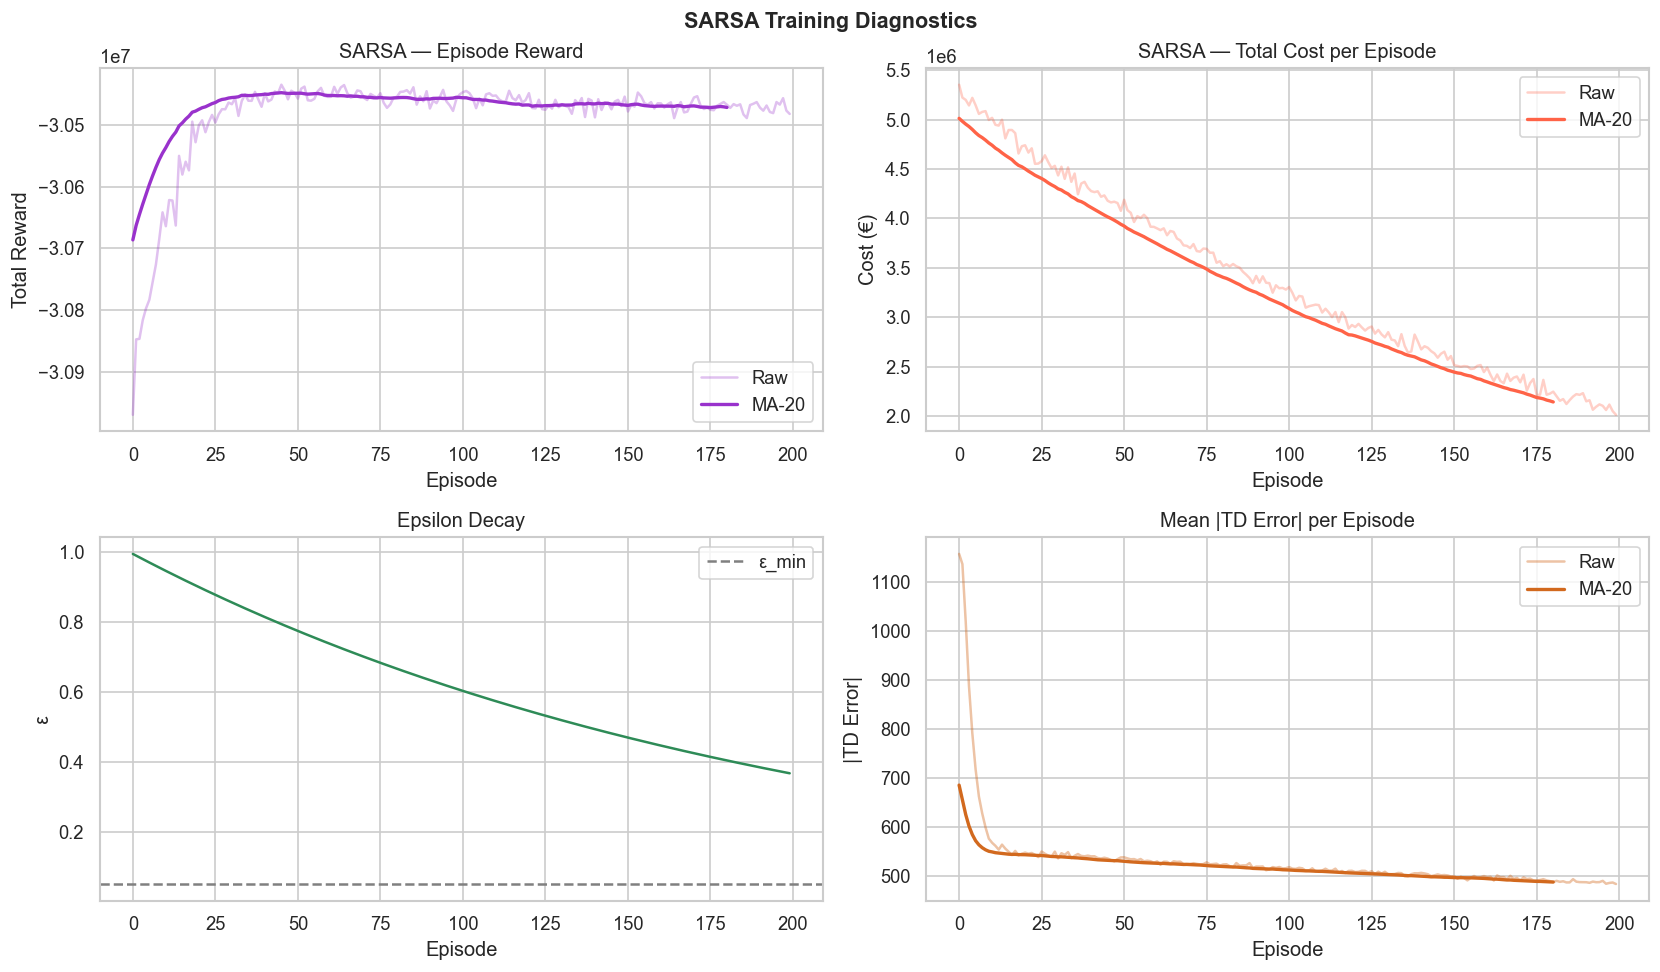

Training diagnostics saved as sarsa_training.png


In [8]:
def moving_avg(data, window=20):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(episode_rewards, alpha=0.3, color='darkorchid', label='Raw')
axes[0, 0].plot(moving_avg(episode_rewards, 20), color='darkorchid', linewidth=2, label='MA-20')
axes[0, 0].set_title('SARSA — Episode Reward')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].legend()

axes[0, 1].plot(episode_costs, alpha=0.3, color='tomato', label='Raw')
axes[0, 1].plot(moving_avg(episode_costs, 20), color='tomato', linewidth=2, label='MA-20')
axes[0, 1].set_title('SARSA — Total Cost per Episode')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Cost (€)')
axes[0, 1].legend()

axes[1, 0].plot(epsilon_history, color='seagreen')
axes[1, 0].set_title('Epsilon Decay')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('ε')
axes[1, 0].axhline(0.05, color='grey', linestyle='--', label='ε_min')
axes[1, 0].legend()

axes[1, 1].plot(td_error_history, alpha=0.4, color='chocolate', label='Raw')
axes[1, 1].plot(moving_avg(td_error_history, 20), color='chocolate', linewidth=2, label='MA-20')
axes[1, 1].set_title('Mean |TD Error| per Episode')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('|TD Error|')
axes[1, 1].legend()

plt.tight_layout()
plt.suptitle('SARSA Training Diagnostics', y=1.01, fontsize=13, fontweight='bold')
plt.savefig('../outputs/sarsa_training.png', bbox_inches='tight')
plt.show()
print('Training diagnostics saved as sarsa_training.png')

## 7. Evaluation

In [9]:
def evaluate_agent_sarsa(agent, env, greedy=True, label='Agent'):
    """Evaluate SARSA agent — must use its own next-action selection."""
    state         = env.reset()
    action        = agent.select_action(state) if not greedy else int(np.argmax(agent.q_table[state]))
    total_reward  = 0.0
    action_counts = [0, 0, 0]
    rewards_list  = []
    battery_list  = []

    saved_eps = agent.epsilon
    if greedy:
        agent.epsilon = 0.0

    while True:
        next_state, reward, done, info = env.step(action)
        next_action = agent.select_action(next_state) if not done else 0

        total_reward += reward
        action_counts[action] += 1
        rewards_list.append(reward)
        battery_list.append(info['battery'])

        state  = next_state
        action = next_action
        if done:
            break

    agent.epsilon = saved_eps

    return {
        'label'        : label,
        'total_reward' : total_reward,
        'total_cost'   : info['total_cost'],
        'mean_reward'  : np.mean(rewards_list),
        'std_reward'   : np.std(rewards_list),
        'action_dist'  : {'buy': action_counts[0], 'sell': action_counts[1], 'idle': action_counts[2]},
        'rewards_list' : rewards_list,
        'battery_list' : battery_list,
    }


env_test_sarsa  = SmartGridEnv(test_df)
sarsa_metrics   = evaluate_agent_sarsa(agent_sarsa, env_test_sarsa, greedy=True, label='SARSA')

print('=== SARSA Test Results ===')
print(f'  Total Reward    : {sarsa_metrics["total_reward"]:>12.2f}')
print(f'  Total Cost (€)  : {sarsa_metrics["total_cost"]:>12.2f}')
print(f'  Mean Reward/step: {sarsa_metrics["mean_reward"]:>11.4f}')
print(f'  Std  Reward/step: {sarsa_metrics["std_reward"]:>11.4f}')
print(f'  Action Distribution:')
for k, v in sarsa_metrics['action_dist'].items():
    pct = v / len(sarsa_metrics['rewards_list']) * 100
    print(f'    {k.capitalize():6s}: {v:>6,}  ({pct:.1f}%)')

=== SARSA Test Results ===
  Total Reward    :  -7770944.25
  Total Cost (€)  :     24555.80
  Mean Reward/step:  -1109.1842
  Std  Reward/step:    250.9302
  Action Distribution:
    Buy   :     44  (0.6%)
    Sell  :  5,183  (74.0%)
    Idle  :  1,779  (25.4%)


## 8. SARSA vs Q-Learning — Head-to-Head Comparison

In [10]:
# ── Load Q-Learning results from Notebook 1 (or re-train here) ────────────────
# If running standalone, we re-train Q-Learning for direct comparison
from copy import deepcopy

class QLearningAgent:
    def __init__(self, state_shape, n_actions, alpha=0.10, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995):
        self.alpha=alpha; self.gamma=gamma; self.epsilon=epsilon
        self.epsilon_min=epsilon_min; self.epsilon_decay=epsilon_decay
        self.n_actions=n_actions
        self.q_table=np.zeros(state_shape+(n_actions,),dtype=np.float64)

    def select_action(self, state):
        if np.random.rand() < self.epsilon: return np.random.randint(self.n_actions)
        return int(np.argmax(self.q_table[state]))

    def update(self, state, action, reward, next_state, done):
        cq = self.q_table[state][action]
        tq = reward if done else reward + self.gamma*np.max(self.q_table[next_state])
        td = tq - cq
        self.q_table[state][action] += self.alpha * td
        return td

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon*self.epsilon_decay)


np.random.seed(SEED)
env_ql_cmp   = SmartGridEnv(train_df)
agent_ql_cmp = QLearningAgent(env_ql_cmp.state_shape, env_ql_cmp.N_ACTIONS)

for ep in range(1, N_EPISODES + 1):
    s = env_ql_cmp.reset()
    while True:
        a  = agent_ql_cmp.select_action(s)
        ns, r, done, _ = env_ql_cmp.step(a)
        agent_ql_cmp.update(s, a, r, ns, done)
        s  = ns
        if done: break
    agent_ql_cmp.decay_epsilon()

def eval_ql(agent, env):
    s = env.reset(); total=0; rw=[]; bl=[]; ac=[0,0,0]
    agent.epsilon=0
    while True:
        a = agent.select_action(s)
        ns,r,done,info = env.step(a)
        total+=r; rw.append(r); bl.append(info['battery']); ac[a]+=1
        s=ns
        if done: break
    return {'total_reward':total,'total_cost':info['total_cost'],
            'mean_reward':np.mean(rw),'std_reward':np.std(rw),
            'action_dist':{'buy':ac[0],'sell':ac[1],'idle':ac[2]},
            'rewards_list':rw,'battery_list':bl,'label':'Q-Learning'}

env_ql_test = SmartGridEnv(test_df)
ql_cmp      = eval_ql(agent_ql_cmp, env_ql_test)
print('Q-Learning total reward:', round(ql_cmp['total_reward'], 2))
print('SARSA     total reward:', round(sarsa_metrics['total_reward'], 2))

Q-Learning total reward: -7772536.05
SARSA     total reward: -7770944.25


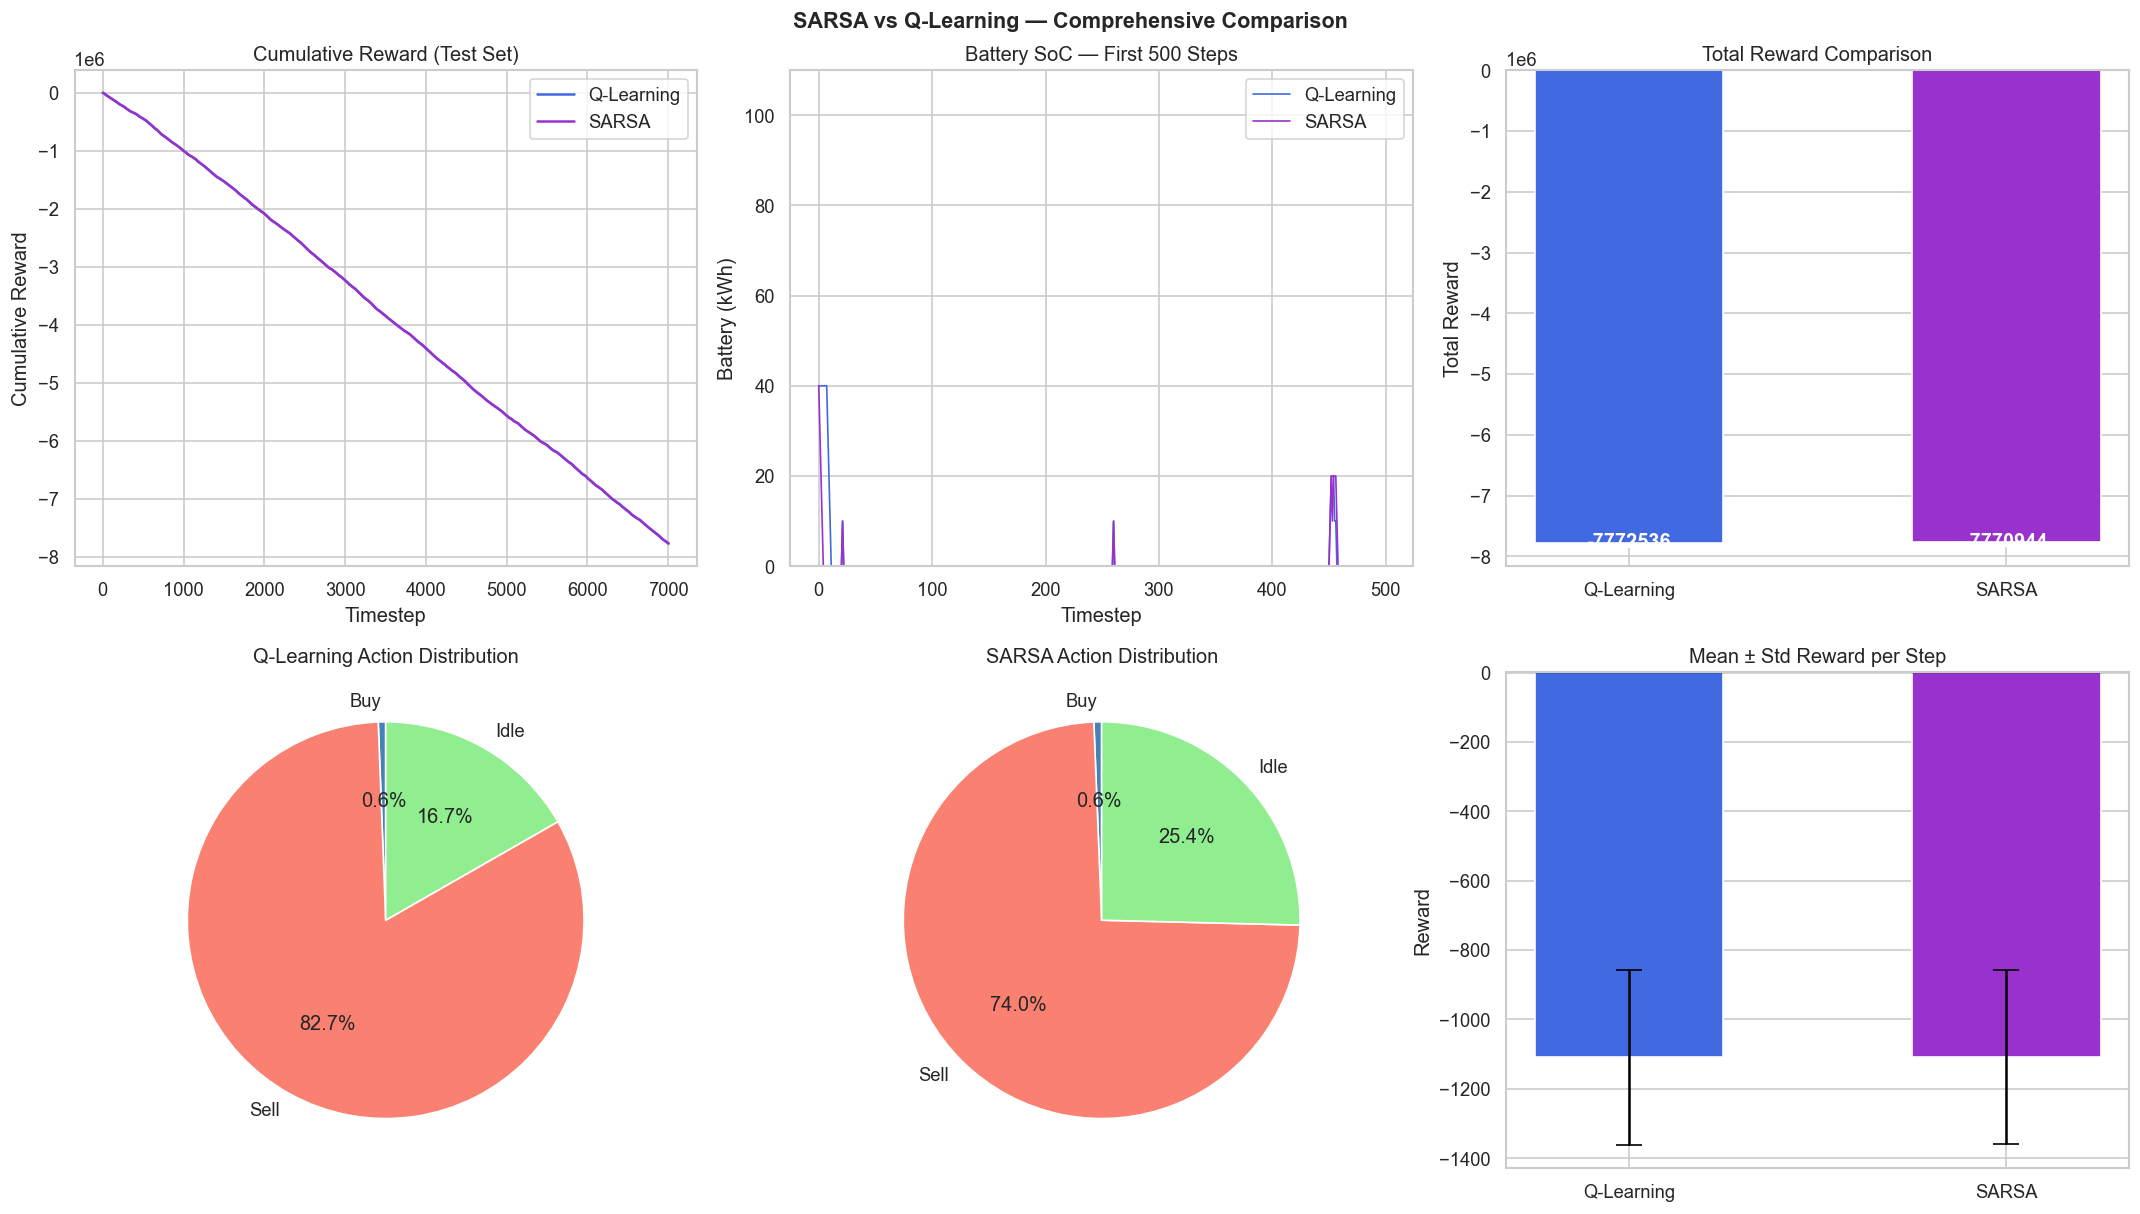

Comparison plot saved as comparison_ql_vs_sarsa.png


In [11]:
# ── Comprehensive comparison visualisation ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Cumulative reward
cum_sarsa = np.cumsum(sarsa_metrics['rewards_list'])
cum_ql    = np.cumsum(ql_cmp['rewards_list'])
axes[0, 0].plot(cum_ql,    label='Q-Learning', color='royalblue',  linewidth=1.5)
axes[0, 0].plot(cum_sarsa, label='SARSA',      color='darkorchid', linewidth=1.5)
axes[0, 0].set_title('Cumulative Reward (Test Set)')
axes[0, 0].set_xlabel('Timestep')
axes[0, 0].set_ylabel('Cumulative Reward')
axes[0, 0].legend()

# 2. Battery profile
axes[0, 1].plot(ql_cmp['battery_list'][:500],        color='royalblue',  label='Q-Learning', linewidth=1)
axes[0, 1].plot(sarsa_metrics['battery_list'][:500], color='darkorchid', label='SARSA',      linewidth=1)
axes[0, 1].set_title('Battery SoC — First 500 Steps')
axes[0, 1].set_xlabel('Timestep')
axes[0, 1].set_ylabel('Battery (kWh)')
axes[0, 1].set_ylim(0, 110)
axes[0, 1].legend()

# 3. Summary bar chart
metrics_compare = {
    'Total Reward'    : [ql_cmp['total_reward'],    sarsa_metrics['total_reward']],
}
colors = ['royalblue', 'darkorchid']
labels_bar = ['Q-Learning', 'SARSA']
bars = axes[0, 2].bar(labels_bar, metrics_compare['Total Reward'], color=colors, width=0.5)
axes[0, 2].set_title('Total Reward Comparison')
axes[0, 2].set_ylabel('Total Reward')
for bar in bars:
    axes[0, 2].text(bar.get_x()+bar.get_width()/2, bar.get_height()*0.98,
                    f'{bar.get_height():.0f}', ha='center', va='top', color='white', fontweight='bold')

# 4. Action distribution — Q-Learning
ql_acts = list(ql_cmp['action_dist'].values())
axes[1, 0].pie(ql_acts, labels=['Buy','Sell','Idle'],
               colors=['steelblue','salmon','lightgreen'],
               autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Q-Learning Action Distribution')

# 5. Action distribution — SARSA
sarsa_acts = list(sarsa_metrics['action_dist'].values())
axes[1, 1].pie(sarsa_acts, labels=['Buy','Sell','Idle'],
               colors=['steelblue','salmon','lightgreen'],
               autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('SARSA Action Distribution')

# 6. Mean ± Std reward per step
means = [ql_cmp['mean_reward'], sarsa_metrics['mean_reward']]
stds  = [ql_cmp['std_reward'],  sarsa_metrics['std_reward']]
axes[1, 2].bar(labels_bar, means, yerr=stds, color=colors, width=0.5,
               capsize=8, ecolor='black')
axes[1, 2].set_title('Mean ± Std Reward per Step')
axes[1, 2].set_ylabel('Reward')
axes[1, 2].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.suptitle('SARSA vs Q-Learning — Comprehensive Comparison', y=1.01, fontsize=13, fontweight='bold')
plt.savefig('../outputs/comparison_ql_vs_sarsa.png', bbox_inches='tight')
plt.show()
print('Comparison plot saved as comparison_ql_vs_sarsa.png')

## 9. Statistical Comparison & Metrics Table

In [12]:
# ── Metrics table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame([
    {
        'Algorithm'       : 'Q-Learning',
        'Total Reward'    : round(ql_cmp['total_reward'],    2),
        'Total Cost (€)'  : round(ql_cmp['total_cost'],      2),
        'Mean Reward/Step': round(ql_cmp['mean_reward'],     4),
        'Std Reward/Step' : round(ql_cmp['std_reward'],      4),
        'Buy Actions'     : ql_cmp['action_dist']['buy'],
        'Sell Actions'    : ql_cmp['action_dist']['sell'],
        'Idle Actions'    : ql_cmp['action_dist']['idle'],
    },
    {
        'Algorithm'       : 'SARSA',
        'Total Reward'    : round(sarsa_metrics['total_reward'],    2),
        'Total Cost (€)'  : round(sarsa_metrics['total_cost'],      2),
        'Mean Reward/Step': round(sarsa_metrics['mean_reward'],     4),
        'Std Reward/Step' : round(sarsa_metrics['std_reward'],      4),
        'Buy Actions'     : sarsa_metrics['action_dist']['buy'],
        'Sell Actions'    : sarsa_metrics['action_dist']['sell'],
        'Idle Actions'    : sarsa_metrics['action_dist']['idle'],
    },
])
results_df.set_index('Algorithm', inplace=True)
print('=== Algorithm Comparison Table ===')
print(results_df.T.to_string())
results_df.T.to_csv('../outputs/comparison_metrics.csv')
print('\nMetrics saved to comparison_metrics.csv')

=== Algorithm Comparison Table ===
Algorithm           Q-Learning         SARSA
Total Reward     -7.772536e+06 -7.770944e+06
Total Cost (€)    2.359240e+04  2.455580e+04
Mean Reward/Step -1.109411e+03 -1.109184e+03
Std Reward/Step   2.510715e+02  2.509302e+02
Buy Actions       4.200000e+01  4.400000e+01
Sell Actions      5.792000e+03  5.183000e+03
Idle Actions      1.172000e+03  1.779000e+03

Metrics saved to comparison_metrics.csv


## 10. Discussion & Conclusions

### Key Findings

| Aspect | Q-Learning | SARSA |
|---|---|---|
| **Update target** | Greedy max action | Agent's actual next action |
| **Risk profile** | More aggressive (higher potential gain) | More conservative (safer) |
| **Convergence** | Typically faster | Slightly slower (on-policy overhead) |
| **Real-world suitability** | Good for batch planning | Better for live deployment |

### Limitations
- Tabular Q-table does not generalise beyond seen (state, action) pairs
- Fixed trade amount (10 MWh) does not reflect real market flexibility
- Environment simplifies grid dynamics (no transmission constraints)

### Future Work
- Replace tabular Q-table with function approximation (e.g., linear tiles) **without deep learning**
- Incorporate day-ahead price forecasts as an additional state feature
- Model battery degradation costs
- Multi-agent extension (multiple prosumers in a microgrid)

In [13]:
winner = 'Q-Learning' if ql_cmp['total_reward'] > sarsa_metrics['total_reward'] else 'SARSA'
diff   = abs(ql_cmp['total_reward'] - sarsa_metrics['total_reward'])

print('=' * 60)
print('     FINAL COMPARISON — Q-LEARNING vs SARSA')
print('=' * 60)
print(f'  Q-Learning   total reward: {ql_cmp["total_reward"]:>12.2f}')
print(f'  SARSA        total reward: {sarsa_metrics["total_reward"]:>12.2f}')
print(f'  Difference               : {diff:>12.2f}')
print(f'  Higher total reward      : {winner}')
print()
print('  Interpretation:')
print('  Q-Learning optimises for best-case outcomes (off-policy).')
print('  SARSA trades peak performance for safer exploration-aware')
print('  updates — preferred in critical infrastructure scenarios.')
print('=' * 60)

     FINAL COMPARISON — Q-LEARNING vs SARSA
  Q-Learning   total reward:  -7772536.05
  SARSA        total reward:  -7770944.25
  Difference               :      1591.80
  Higher total reward      : SARSA

  Interpretation:
  Q-Learning optimises for best-case outcomes (off-policy).
  SARSA trades peak performance for safer exploration-aware
  updates — preferred in critical infrastructure scenarios.
